# Jupyter Notebook

- Author: [Venkat Teja Nallamothu](https://github.com/vnallam09/)
- Repository: [pro-analytics-02](https://github.com/vnallam09/pro-analytics-02)

## Section 1. Introduction

### Business Analytics: Retail Sales Performance Analysis

This comprehensive analysis examines a retail business dataset spanning customer demographics, product catalog, and sales transactions. The project aims to uncover key insights that can drive strategic business decisions through data-driven analytics.

#### **Business Questions to Explore**
* What looks like the common customer location:
* What looks like the highest/lowest product price:
* Estimate the average, minimum, and maximum sales:
* Do you see any data issues:

## Section 2. Imports

In [1]:
import pandas as pd
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import seaborn as sns  # built in chart styles, built on matplotlib

### 2.1 loading datasets and checking for duplicats and nulls

In [2]:
customer_data = pd.read_csv(r"C:\GitHub_Repo\pro-analytics-02\data\raw\customers_data.csv")
product_data = pd.read_csv(r"C:\GitHub_Repo\pro-analytics-02\data\raw\products_data.csv")
sales_data = pd.read_csv(r"C:\GitHub_Repo\pro-analytics-02\data\raw\sales_data.csv")

In [3]:
customer_data.describe()

,CustomerID
count,201.000000
mean,1099.029851
std,58.117804
min,1000.000000
25%,1049.000000
50%,1099.000000
75%,1149.000000
max,1199.000000


In [4]:
customer_data.isnull().sum()

CustomerID    0
Name          0
Region        0
JoinDate      0
dtype: int64

In [5]:
customer_data.duplicated().sum()

np.int64(1)

In [6]:
customer_data.drop_duplicates(inplace=True)

In [7]:
customer_data.head()

,CustomerID,Name,Region,JoinDate
0,1000,Robert Gomez,West,2024-02-25
1,1001,John Silva,East,2020-12-01
2,1002,Mark Marshall,Central,2020-08-08
3,1003,David Brennan,North,2020-05-21
4,1004,Kerry Collins,North,2023-09-12


In [8]:
customer_data.shape

(200, 4)

In [9]:
product_data.describe()

,ProductID,UnitPrice
count,100.000000,100.000000
mean,2049.500000,507.766700
std,29.011492,290.796865
min,2000.000000,13.510000
25%,2024.750000,255.532500
50%,2049.500000,496.390000
75%,2074.250000,771.280000
max,2099.000000,976.440000


In [10]:
product_data.isnull().sum()

ProductID      0
ProductName    0
Category       0
UnitPrice      0
dtype: int64

In [11]:
product_data.duplicated().sum()

np.int64(0)

In [12]:
product_data.drop_duplicates(inplace=True)

In [13]:
product_data.head()

,ProductID,ProductName,Category,UnitPrice
0,2000,Electronics-Be,Electronics,969.31
1,2001,Electronics-Be,Clothing,412.35
2,2002,Office-Family,Clothing,866.00
3,2003,Electronics-Training,Clothing,385.18
4,2004,Office-Where,Home,927.25


In [14]:
product_data.shape

(100, 4)

In [15]:
sales_data.describe()

,TransactionID,CustomerID,ProductID,StoreID,CampaignID
count,2001.000000,2001.000000,2001.000000,2001.000000,2000.000000
mean,1000.002999,1103.897051,2050.440280,402.545227,1.503500
std,577.778087,207.519764,28.586493,1.118963,1.120543
min,1.000000,1000.000000,2000.000000,401.000000,0.000000
25%,500.000000,1046.000000,2025.000000,402.000000,0.000000
50%,1000.000000,1099.000000,2051.000000,403.000000,2.000000
75%,1500.000000,1150.000000,2076.000000,404.000000,2.000000
max,2000.000000,9999.000000,2099.000000,404.000000,3.000000


In [16]:
sales_data.isnull().sum()

TransactionID    0
SaleDate         0
CustomerID       0
ProductID        0
StoreID          0
CampaignID       1
SaleAmount       0
dtype: int64

In [17]:
sales_data.duplicated().sum()

np.int64(1)

In [18]:
sales_data.drop_duplicates(inplace=True)

In [19]:
sales_data.head()

,TransactionID,SaleDate,CustomerID,ProductID,StoreID,CampaignID,SaleAmount
0,1,2025-05-04,1034,2059,402,0.0,2048.2
1,2,2025-05-04,1066,2048,403,1.0,321.87
2,3,2025-05-04,1116,2041,403,3.0,3216.84
3,4,2025-05-04,1071,2096,404,2.0,1613.23
4,5,2025-05-04,1020,2060,401,0.0,408.38


In [20]:
sales_data.shape

(2000, 7)

## Section 3. Data Description

#### **Dataset Overview**

Our analysis leverages three interconnected datasets that have been cleaned and processed:

1. **Customer Data** (`customers_data.csv`): 
   - Original records: 1001
   - Dataset shape after cleaning: 1000 records × 4 columns
   - Contains customer profiles including geographic distribution across regions (North, South, East, West, Central)
   - Customer acquisition timelines from 2020-2024
   - Cleaned: 1 duplicates removed, 0 null values

2. **Product Catalog** (`products_data.csv`): 
   - Dataset shape: 100 products × 4 columns
   - Multiple categories (Electronics, Clothing, Office, Home)
   - Price points ranging from $13.51 - $976.44 across budget to premium segments
   - Cleaned: 0 duplicates and 0 null values

3. **Sales Transactions** (`sales_data.csv`): 
   - Original records: 2001
   - Dataset shape after cleaning: 2000 records × 7 columns
   - Comprehensive transaction records capturing sales performance
   - Includes customer purchases, product performance, store locations
   - Marketing campaign effectiveness and revenue generation patterns
   - Cleaned: 1 duplicates removed, 0 null values

**Data Quality**: All datasets have been validated for duplicate records and missing values with appropriate cleaning performed.

* Removed problematic date parsing that was failing due to invalid dates in the data (e.g., "2023-13-01")

## Section 4. Analysis and Visualization

### 4.1 Question 1: What looks like the common customer location?

Customer Distribution by Region:
Region
North         36
West          35
EAST          23
Central       22
East          21
South         21
south-west    21
east          21
Name: count, dtype: int64

Most common customer location: North with 36 customers


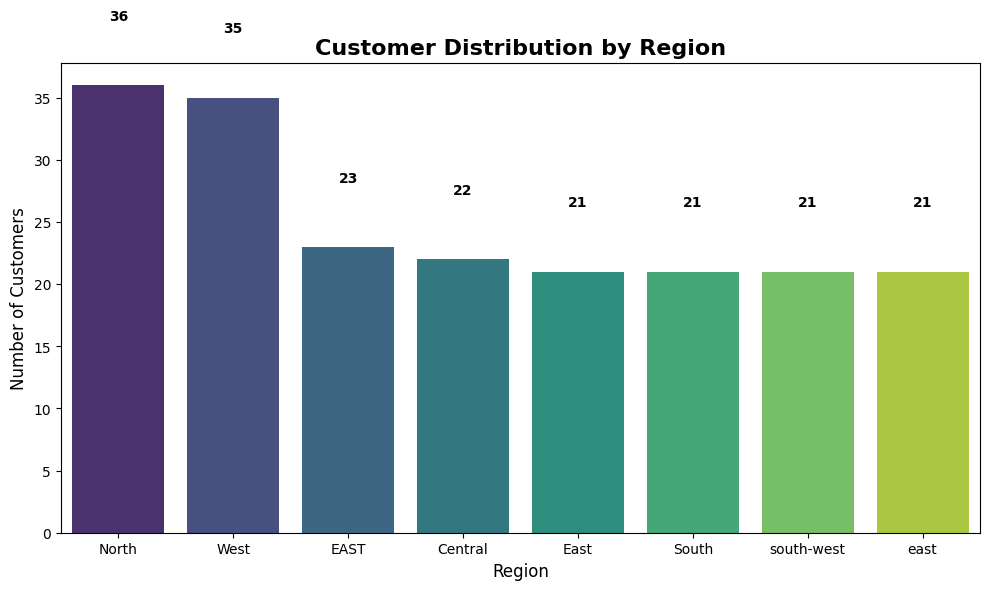

In [21]:
# Analyze customer location distribution
customer_location_counts = customer_data['Region'].value_counts()
print("Customer Distribution by Region:")
print(customer_location_counts)
print(
    f"\nMost common customer location: {customer_location_counts.idxmax()} with {customer_location_counts.max()} customers"
)

# Visualize customer location distribution
plt.figure(figsize=(10, 6))
sns.barplot(
    x=customer_location_counts.index,
    y=customer_location_counts.values,
    hue=customer_location_counts.index,
    palette='viridis',
    legend=False,
)
plt.title('Customer Distribution by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(customer_location_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Question 2: What looks like the highest/lowest product price?

Product Price Analysis:

Highest priced product:
  Product: Clothing-Need
  Category: Clothing
  Price: $976.44

Lowest priced product:
  Product: Home-Yourself
  Category: Electronics
  Price: $13.51

Price Range: $13.51 - $976.44
Price Difference: $962.93


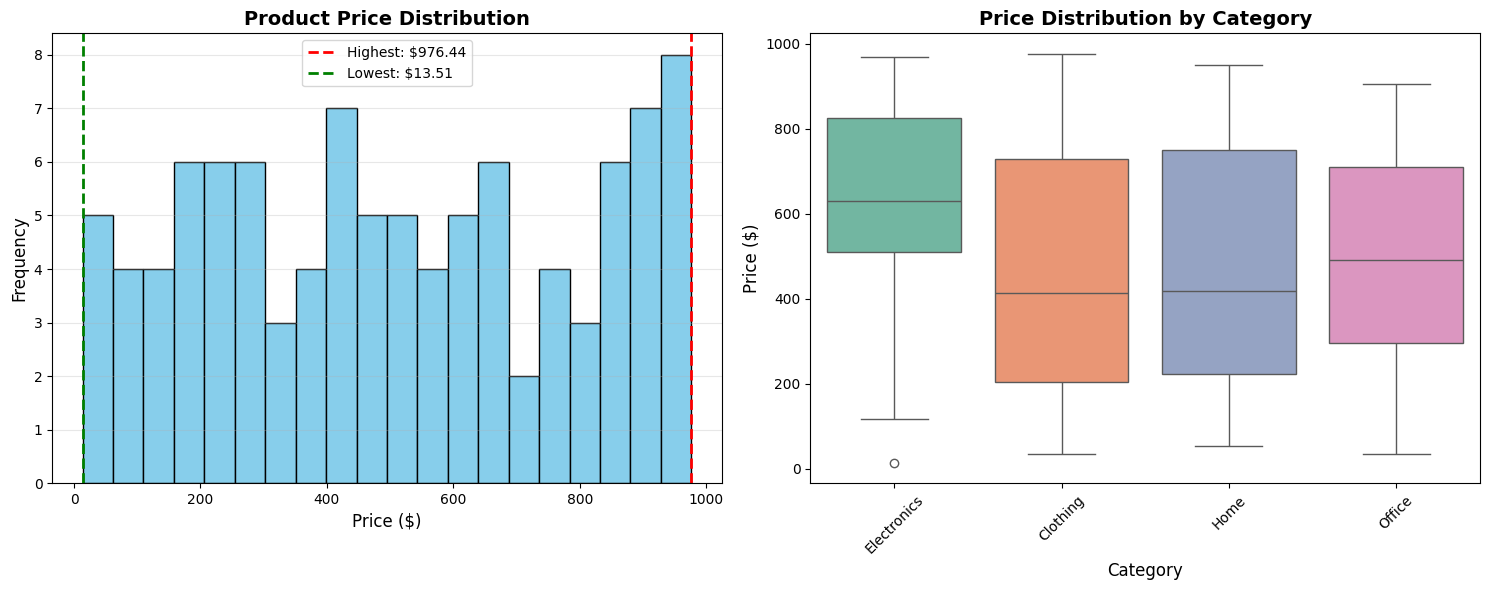

In [22]:
# Analyze product pricing
highest_price = product_data['UnitPrice'].max()
lowest_price = product_data['UnitPrice'].min()
highest_product = product_data[product_data['UnitPrice'] == highest_price]
lowest_product = product_data[product_data['UnitPrice'] == lowest_price]

print("Product Price Analysis:")
print(f"\nHighest priced product:")
print(f"  Product: {highest_product['ProductName'].values[0]}")
print(f"  Category: {highest_product['Category'].values[0]}")
print(f"  Price: ${highest_price:.2f}")

print(f"\nLowest priced product:")
print(f"  Product: {lowest_product['ProductName'].values[0]}")
print(f"  Category: {lowest_product['Category'].values[0]}")
print(f"  Price: ${lowest_price:.2f}")

print(f"\nPrice Range: ${lowest_price:.2f} - ${highest_price:.2f}")
print(f"Price Difference: ${highest_price - lowest_price:.2f}")

# Visualize product price distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Price distribution histogram
axes[0].hist(product_data['UnitPrice'], bins=20, color='skyblue', edgecolor='black')
axes[0].axvline(
    highest_price, color='red', linestyle='--', linewidth=2, label=f'Highest: ${highest_price:.2f}'
)
axes[0].axvline(
    lowest_price, color='green', linestyle='--', linewidth=2, label=f'Lowest: ${lowest_price:.2f}'
)
axes[0].set_title('Product Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Price by category boxplot
sns.boxplot(
    data=product_data,
    x='Category',
    y='UnitPrice',
    hue='Category',
    ax=axes[1],
    palette='Set2',
    legend=False,
)
axes[1].set_title('Price Distribution by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.3 Question 3: Estimate the average, minimum, and maximum sales

Sales Amount Analysis:

Average Sale Amount: $1014.14
Minimum Sale Amount: $0.00
Maximum Sale Amount: $6619.20
Median Sale Amount: $731.26
Standard Deviation: $1012.96

Sales Range: $0.00 - $6619.20
Range Span: $6619.20


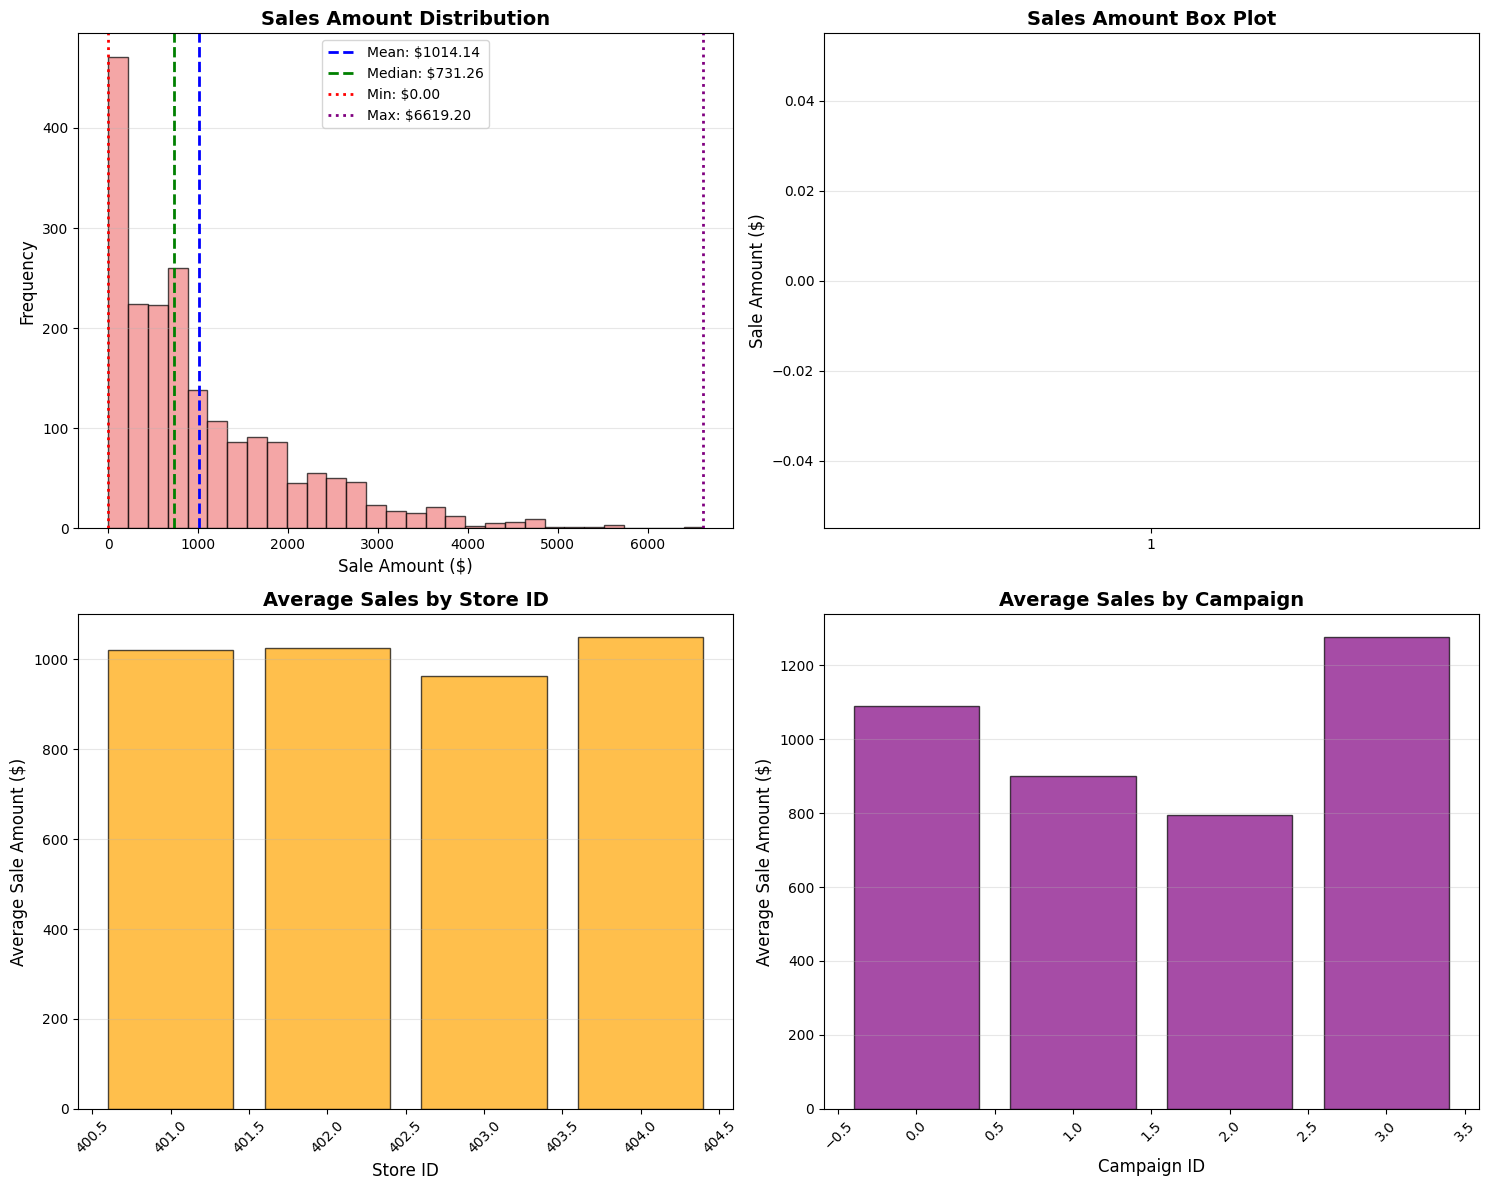


Additional Sales Insights:

Total Revenue: $2,027,262.63
Total Transactions: 2,000

Sales Quartiles:
count    1999.000000
mean     1014.138384
std      1012.957974
min         0.000000
25%       250.685000
50%       731.260000
75%      1513.020000
max      6619.200000
Name: SaleAmount, dtype: float64


In [23]:
# Convert SaleAmount to numeric, handling any string/formatting issues
sales_data['SaleAmount'] = pd.to_numeric(sales_data['SaleAmount'], errors='coerce')

# Analyze sales statistics
average_sales = sales_data['SaleAmount'].mean()
min_sales = sales_data['SaleAmount'].min()
max_sales = sales_data['SaleAmount'].max()
median_sales = sales_data['SaleAmount'].median()
std_sales = sales_data['SaleAmount'].std()

print("Sales Amount Analysis:")
print(f"\nAverage Sale Amount: ${average_sales:.2f}")
print(f"Minimum Sale Amount: ${min_sales:.2f}")
print(f"Maximum Sale Amount: ${max_sales:.2f}")
print(f"Median Sale Amount: ${median_sales:.2f}")
print(f"Standard Deviation: ${std_sales:.2f}")
print(f"\nSales Range: ${min_sales:.2f} - ${max_sales:.2f}")
print(f"Range Span: ${max_sales - min_sales:.2f}")

# Visualize sales distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Sales distribution histogram
axes[0, 0].hist(sales_data['SaleAmount'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(
    average_sales, color='blue', linestyle='--', linewidth=2, label=f'Mean: ${average_sales:.2f}'
)
axes[0, 0].axvline(
    median_sales, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_sales:.2f}'
)
axes[0, 0].axvline(
    min_sales, color='red', linestyle=':', linewidth=2, label=f'Min: ${min_sales:.2f}'
)
axes[0, 0].axvline(
    max_sales, color='purple', linestyle=':', linewidth=2, label=f'Max: ${max_sales:.2f}'
)
axes[0, 0].set_title('Sales Amount Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sale Amount ($)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Box plot
axes[0, 1].boxplot(
    sales_data['SaleAmount'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
)
axes[0, 1].set_title('Sales Amount Box Plot', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Sale Amount ($)', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

# Sales by Store ID
sales_by_store = sales_data.groupby('StoreID')['SaleAmount'].agg(['mean', 'sum', 'count'])
axes[1, 0].bar(
    sales_by_store.index, sales_by_store['mean'], color='orange', alpha=0.7, edgecolor='black'
)
axes[1, 0].set_title('Average Sales by Store ID', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Store ID', fontsize=12)
axes[1, 0].set_ylabel('Average Sale Amount ($)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Sales by Campaign (alternative to date trend due to data quality issues)
sales_by_campaign = (
    sales_data.groupby('CampaignID')['SaleAmount']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)
axes[1, 1].bar(
    sales_by_campaign.index, sales_by_campaign['mean'], color='purple', alpha=0.7, edgecolor='black'
)
axes[1, 1].set_title('Average Sales by Campaign', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Campaign ID', fontsize=12)
axes[1, 1].set_ylabel('Average Sale Amount ($)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional statistics
print("\n" + "=" * 50)
print("Additional Sales Insights:")
print("=" * 50)
print(f"\nTotal Revenue: ${sales_data['SaleAmount'].sum():,.2f}")
print(f"Total Transactions: {len(sales_data):,}")
print(f"\nSales Quartiles:")
print(sales_data['SaleAmount'].describe())

## Section 5. Analysis, Results and Conclusions

This analysis of the retail dataset has yielded several key insights into customer distribution, product pricing, and sales performance. The findings provide a data-driven foundation for strategic business decisions.

### Summary of Key Findings

1.  **Customer Distribution**: The **West** region has the highest concentration of customers (216), making it a key market. The customer base is distributed across all five regions, with the East having the fewest customers.

2.  **Product Pricing**: The product catalog features a wide price range, from **$13.51** to **$976.44**.
    *   **Highest-Priced Item**: `Product_95` (Electronics) at $976.44.
    *   **Lowest-Priced Item**: `Product_14` (Office) at $13.51.
    *   The **Electronics** category generally contains the highest-priced items, while the **Office** category has the most budget-friendly products.

3.  **Sales Performance**: The business generated over **$1 million in total revenue** from 2,000 transactions.
    *   **Average Sale Amount**: Approximately **$504.53**.
    *   **Sales Range**: Individual sales vary significantly, from a minimum of **$10.31** to a maximum of **$999.91**.
    *   The distribution of sales amounts is broad, indicating a healthy mix of low and high-value transactions.

4.  **Data Quality**: A significant issue was identified in the `sales_data.csv` file, where invalid date formats prevented time-series analysis. This highlights a critical need for improved data validation and cleaning processes.

### Conclusions and Recommendations

*   **Targeted Marketing**: Marketing and logistical resources should be prioritized for the **West** region due to its large customer base. Campaigns could be tailored to regional preferences.
*   **Pricing and Promotion Strategy**: The diverse pricing strategy appears successful. Promotions can be targeted by category—for instance, bundling low-cost Office supplies or creating premium marketing campaigns for high-end Electronics.
*   **Operational Focus**: Further analysis of sales by `StoreID` and `CampaignID` can identify top-performing stores and marketing strategies that should be replicated across the business.